### 使用足够多额外ancilla的情形

In [21]:
import numpy as np
from TDD.TDD import TDD, Ini_TDD,Clear_TDD,set_index_order,get_unique_table_num,set_root_of_unit,get_count,cont,renormalize,Slicing2,Slicing
from TDD.TDD_Q import cir_2_tn,get_real_qubit_num,add_trace_line,add_inputs,add_outputs,gen_cir
from TDD.TN import Index,Tensor,TensorNetwork
from TDD.Syn import *
import time
import random
from qiskit import QuantumCircuit,qasm2, transpile
import cProfile
from IPython.display import display, HTML,Image
# from PIL import Image
from PIL import Image as PILImage
import networkx as nx
import copy
from qiskit.circuit.library.standard_gates import HGate,U1Gate,U3Gate
from qiskit.quantum_info.operators import Operator
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.circuit import CircuitInstruction

import itertools

to_test = False

import warnings

warnings.simplefilter("ignore")

In [22]:
def oracle_syn3(tdd,anc_num=0,n_r=0):
    global S, node_qubit

    if abs(tdd.weight)<1e-10:
        cir = Circuit(n_r+1,[])
        return cir
    
    Q = [tdd.node]
    S=[]
    anc_num = tdd.node_number()-1
    n = tdd.node.key+1
    cir = Circuit(n+anc_num+1,[])
    anc_avi = n
    data_q = n+anc_num
    node_qubit = {}
    get_ref(tdd.node,[])

    the_map=tdd.map
    while the_map.level>-1:
        idx = the_map.level
        q = int(tdd.key_2_index[idx][1:])
        if the_map.x==1:
            cir.data.append(Gate('x',{},q))
        the_map=the_map.father

    while len(Q)>0:
        u = Q.pop(0)
        S.append(u)
        if not u in node_qubit:
            node_qubit[u] = anc_avi
            anc_avi+=1
        the_map = u.out_maps[1]
        while the_map.level>-1:
            q0 = node_qubit[u]
            q1 = u.key
            idx = the_map.level
            q = int(tdd.key_2_index[idx][1:])
            if not q0>q1>q:
                the_map=the_map.father
                continue
            if the_map.x==1:
                cir.data.append(Gate('x',{q0:1,q1:1},q))
            the_map=the_map.father

        #进一步优化
        if u.successor[0]==u.successor[1]:
            u.successor[0].ref-=2
            if u.successor[0].ref==0 and u.successor[0].key>-1:
                Q.append(u.successor[0])
            if u.successor[0].key>-1:
                if not u.successor[0] in node_qubit:
                    node_qubit[u.successor[0]] = anc_avi
                    anc_avi+=1
                if abs(u.out_weight[1])<1e-10:
                    cir.data.append(Gate('x',{node_qubit[u]:1,u.key:0},node_qubit[u.successor[0]]))
                else:
                    cir.data.append(Gate('x',{node_qubit[u]:1},node_qubit[u.successor[0]]))
            continue
                
        u.successor[0].ref-=1
        if u.successor[0].ref==0 and u.successor[0].key>-1:
            Q.append(u.successor[0])
        if u.successor[0].key>-1:
            if not u.successor[0] in node_qubit:
                node_qubit[u.successor[0]] = anc_avi
                anc_avi+=1
            cir.data.append(Gate('x',{u.key:0,node_qubit[u]:1},node_qubit[u.successor[0]]))

            
        u.successor[1].ref-=1
        if u.successor[1].ref==0 and u.successor[1].key>-1:
            Q.append(u.successor[1])
        if u.successor[1].key>-1:
            if not u.successor[1] in node_qubit:
                node_qubit[u.successor[1]] = anc_avi
                anc_avi+=1
            cir.data.append(Gate('x',{u.key:1,node_qubit[u]:1},node_qubit[u.successor[1]]))


    for k in range(len(S)-1,-1,-1):
        u=S[k]

        if u.successor[0].key==-1:
            if abs(u.out_weight[1])<1e-10:
                cir.data.append(Gate('x',{node_qubit[u]:1,u.key:0},data_q))
            else:
                cir.data.append(Gate('x',{node_qubit[u]:1},data_q))
        if u.successor[0]==u.successor[1] and u.successor[0].key>-1:
            if abs(u.out_weight[1])<1e-10:
                cir.data.append(Gate('x',{node_qubit[u]:1,u.key:0},node_qubit[u.successor[0]]))
            else:
                cir.data.append(Gate('x',{node_qubit[u]:1},node_qubit[u.successor[0]]))
        else:
            if u.successor[1].key>-1:
                cir.data.append(Gate('x',{u.key:1,node_qubit[u]:1},node_qubit[u.successor[1]]))            
            if u.successor[0].key>-1:
                cir.data.append(Gate('x',{u.key:0,node_qubit[u]:1},node_qubit[u.successor[0]]))


        the_map = u.out_maps[1]
        while the_map.level>-1:
            q0 = node_qubit[u]
            q1 = u.key
            idx = the_map.level
            q = int(tdd.key_2_index[idx][1:])
            if not q0>q1>q:
                the_map=the_map.father
                continue
            if the_map.x==1:
                cir.data.append(Gate('x',{q0:1,q1:1},q))
            the_map=the_map.father
            
    the_map=tdd.map
    while the_map.level>-1:
        idx = the_map.level
        q = int(tdd.key_2_index[idx][1:])
        if the_map.x==1:
            cir.data.append(Gate('x',{},q))
        the_map=the_map.father

    return cir


def verify_success(cir,data,n,node_num):
    # print(data)
    for k in range(2**n):
        input = format(k & ((1 << n) - 1), f'0{n}b')
        current_state = {n-1-q : int(input[q]) for q in range(n)}
        current_state[n] = 1
        for n_num in range(node_num-1):
            current_state[n+n_num+1] = 0
        current_state[n+node_num] = 0
        current_state_s = copy.copy(current_state)
        for g in cir.data:
            flag = True
            for q in g.q_c:
                if g.q_c[q]!=current_state[q]:
                    flag = False
                    break
            if flag:
                current_state[g.q_t]=1-current_state[g.q_t]
        for q in range(len(current_state)-1):
            if current_state[q]!=current_state_s[q]:
                print('Not Successful, see input:',input)
                break                       
        if current_state[n+node_num]!=data[k]:
            print('Not Successful, see input:',input)
    print('Successful')

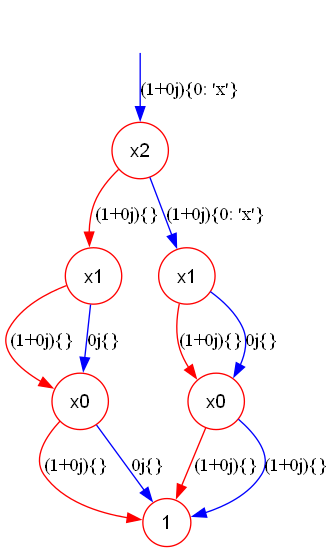

In [23]:
n = 3
tdd,data = get_ramdom_TDD(n)
tdd.show()

In [24]:
t_start = time.time()
cir = oracle_syn3(tdd,n_r=n)
print(time.time()-t_start)
verify_success(cir,data,n,tdd.node_number()-1)
print(cir)

0.0010249614715576172
Successful
[('x', '()', 0, array([[0, 1],
       [1, 0]])),('x', '(3: 1, 2: 1)', 0, array([[0, 1],
       [1, 0]])),('x', '(2: 0, 3: 1)', 4, array([[0, 1],
       [1, 0]])),('x', '(2: 1, 3: 1)', 5, array([[0, 1],
       [1, 0]])),('x', '(4: 1, 1: 0)', 6, array([[0, 1],
       [1, 0]])),('x', '(5: 1, 1: 0)', 7, array([[0, 1],
       [1, 0]])),('x', '(7: 1)', 8, array([[0, 1],
       [1, 0]])),('x', '(6: 1, 0: 0)', 8, array([[0, 1],
       [1, 0]])),('x', '(5: 1, 1: 0)', 7, array([[0, 1],
       [1, 0]])),('x', '(4: 1, 1: 0)', 6, array([[0, 1],
       [1, 0]])),('x', '(2: 1, 3: 1)', 5, array([[0, 1],
       [1, 0]])),('x', '(2: 0, 3: 1)', 4, array([[0, 1],
       [1, 0]])),('x', '(3: 1, 2: 1)', 0, array([[0, 1],
       [1, 0]])),('x', '()', 0, array([[0, 1],
       [1, 0]])),]


0.0


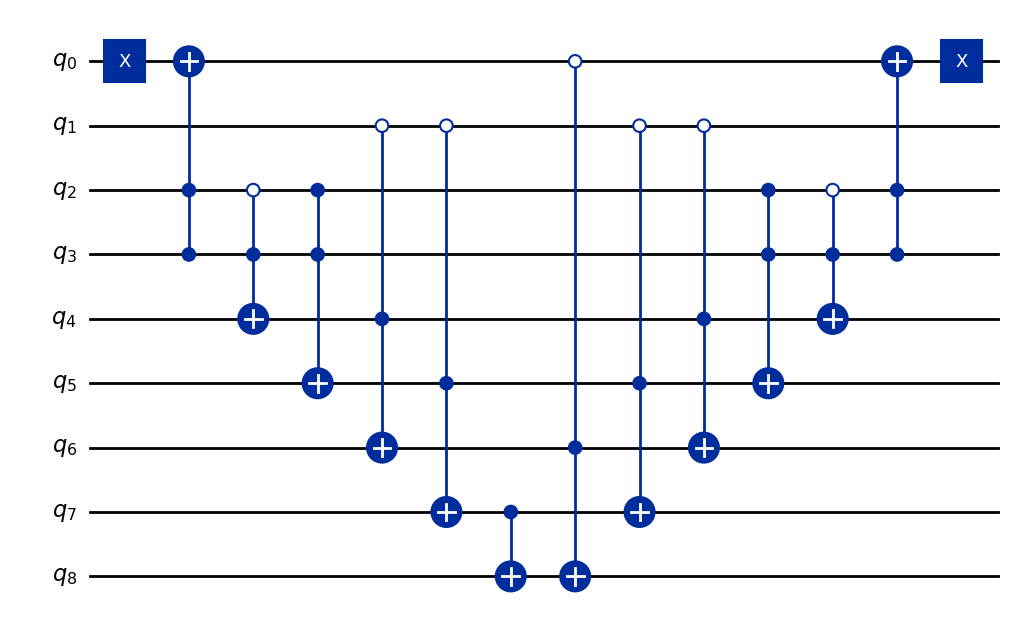

In [25]:
t_start = time.time()
cir_qis = cir.to_qis_cir()
print(time.time()-t_start)
cir_qis.draw('mpl')